# Imágenes con NumPy

**Autor:** Dr. Mitchell Ángel Gómez Ortega
**Fecha:** 05/08/2026

---

# Umbralización de imágenes

La umbralización Thresholding es una técnica de segmentación utilizada para separar el fondo y los objetos de interés en una imagen.

El proceso consiste en comparar cada píxel con un valor umbral previamente definido:

- Si el valor del píxel es mayor que el umbral, se asigna color blanco.
- Si el valor del píxel es menor que el umbral, se asigna color negro.

En este ejemplo se utilizará la imagen `chess.jpg` para aplicar una umbralización global.

---

# Función para visualizar imágenes

Con el propósito de optimizar tiempo y reutilizar código durante las prácticas, se utilizará la siguiente función personalizada para mostrar imágenes.

Esta función permite:

- Crear automáticamente una figura.
- Mostrar la imagen.
- Agregar un título.
- Ocultar los ejes.
- Visualizar el resultado de forma más rápida.

```python
import matplotlib.pyplot as plt

def show_image(image, title=''):

    # Crear figura
    plt.figure(figsize=(6,4))

    # Mostrar imagen
    plt.imshow(image, cmap='gray')

    # Agregar título
    plt.title(title)

    # Quitar ejes
    plt.axis('off')

    # Mostrar resultado
    plt.show()
```

---

# Cargar la imagen

Se carga la imagen `chess.jpg` en escala de grises utilizando `plt.imread()`.

```python
import matplotlib.pyplot as plt

# Cargar imagen en escala de grises
image = plt.imread('../Images/chess.jpg')

# Mostrar imagen original
show_image(image, 'Original')
```

---

# Definir el valor umbral

Se establece un valor umbral para separar el fondo y los objetos de interés de la imagen.

```python
# Definir el valor umbral
thresh = 100
```

---

# Aplicar umbralización

Cada píxel de la imagen se compara con el valor umbral para generar una imagen binaria.

```python
# Aplicar umbralización
binary = image > thresh
```

---

# Mostrar resultados

Finalmente, se visualiza la imagen original y la imagen umbralizada.

```python
# Mostrar imagen original
show_image(image, 'Original')

# Mostrar imagen umbralizada
show_image(binary.astype(float), 'Thresholded')
```

In [43]:
import matplotlib.pyplot as plt

def show_image(image, title=''):

    # Crear figura
    plt.figure(figsize=(6,4))

    # Mostrar imagen
    plt.imshow(image, cmap='gray')

    # Agregar título
    plt.title(title)

    # Quitar ejes
    plt.axis('off')

    # Mostrar resultado
    plt.show()

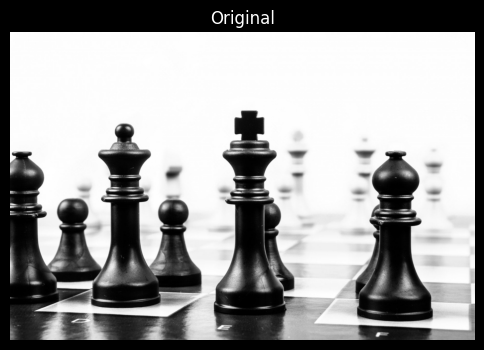

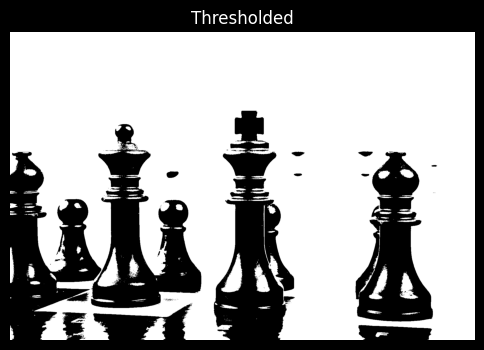

<class 'numpy.ndarray'>
(1271, 1920, 3)
[[[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [251 251 251]
  [251 251 251]
  [251 251 251]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [252 252 252]
  [251 251 251]
  [251 251 251]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [252 252 252]
  [252 252 252]
  [252 252 252]]

 ...

 [[122 122 122]
  [118 118 118]
  [112 112 112]
  ...
  [155 155 155]
  [152 152 152]
  [151 151 151]]

 [[123 123 123]
  [119 119 119]
  [113 113 113]
  ...
  [153 153 153]
  [147 147 147]
  [150 150 150]]

 [[125 125 125]
  [121 121 121]
  [115 115 115]
  ...
  [153 153 153]
  [143 143 143]
  [150 150 150]]]


## Threshold Invertido

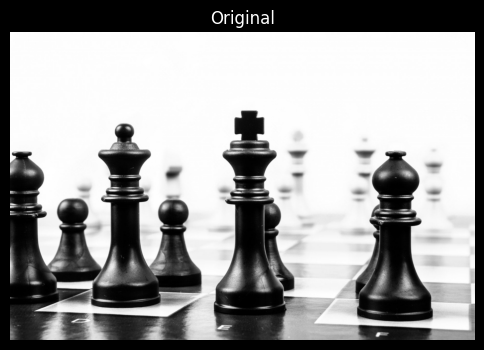

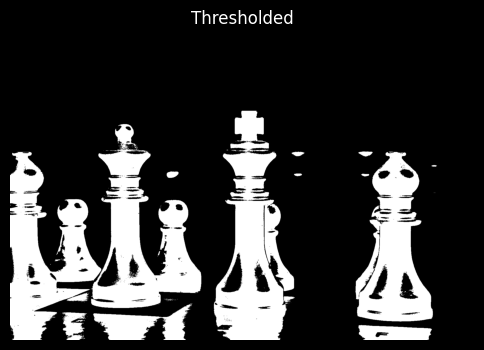

<class 'numpy.ndarray'>
(1271, 1920, 3)
[[[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [251 251 251]
  [251 251 251]
  [251 251 251]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [252 252 252]
  [251 251 251]
  [251 251 251]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [252 252 252]
  [252 252 252]
  [252 252 252]]

 ...

 [[122 122 122]
  [118 118 118]
  [112 112 112]
  ...
  [155 155 155]
  [152 152 152]
  [151 151 151]]

 [[123 123 123]
  [119 119 119]
  [113 113 113]
  ...
  [153 153 153]
  [147 147 147]
  [150 150 150]]

 [[125 125 125]
  [121 121 121]
  [115 115 115]
  ...
  [153 153 153]
  [143 143 143]
  [150 150 150]]]


# Probar diferentes algoritmos de umbralización

La función `try_all_threshold()` permite comparar automáticamente distintos algoritmos de umbralización disponibles en `scikit-image`.

Esta función aplica múltiples métodos sobre la misma imagen y muestra los resultados obtenidos, facilitando la selección del algoritmo más adecuado para cada caso.

---

## Código

```python
from skimage.filters import try_all_threshold
import matplotlib.pyplot as plt

# Cargar imagen
image = plt.imread('../Images/chess.jpg')

# Probar diferentes algoritmos de umbralización
fig, ax = try_all_threshold(image, figsize=(12, 2), verbose=False)

# Mostrar resultados
plt.show()
```

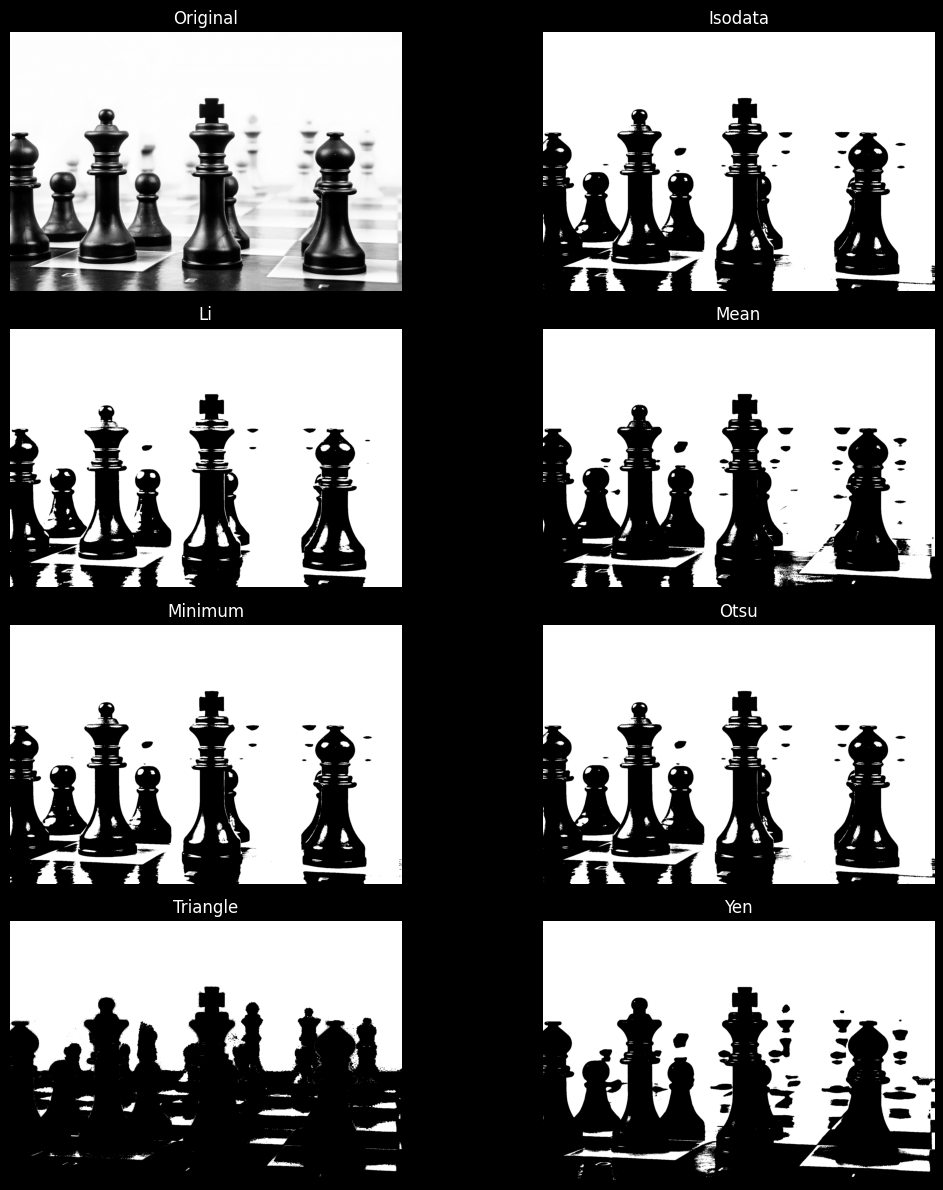

# Umbralización automática con Otsu

El método de Otsu permite calcular automáticamente el valor óptimo de umbral para segmentar una imagen.

Este método analiza el histograma de intensidades y selecciona el valor que mejor separa el fondo y los objetos presentes en la imagen.

---

## Código

```python
from skimage.filters import threshold_otsu
from skimage.color import rgb2gray
import matplotlib.pyplot as plt

# Cargar imagen
image = plt.imread('../Images/chess.jpg')

# Convertir a escala de grises
gray_image = rgb2gray(image)

# Obtener el valor óptimo de umbral
thresh = threshold_otsu(gray_image)

# Aplicar umbralización
binary_global = gray_image > thresh

# Mostrar imagen original
show_image(gray_image, 'Original')

# Mostrar imagen umbralizada
show_image(binary_global.astype(float), 'Thresholded')
```

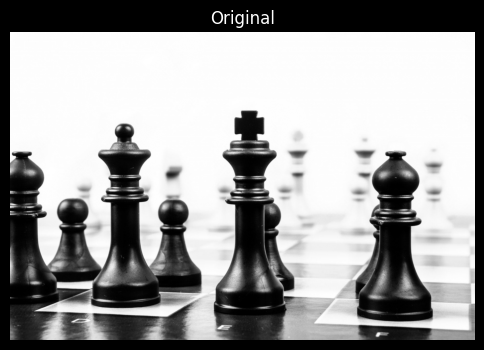

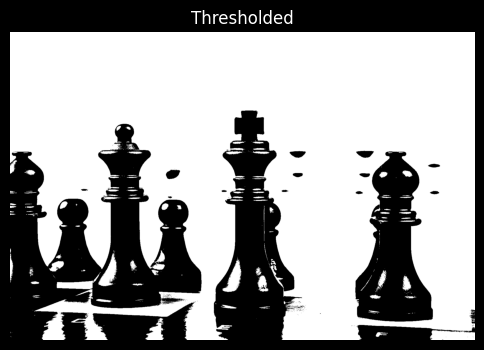

# Umbralización local

La umbralización local se utiliza cuando la imagen presenta iluminación desigual o fondos no uniformes.

A diferencia de la umbralización global, este método calcula diferentes valores de umbral para pequeñas regiones de la imagen, permitiendo segmentaciones más precisas.

---

## Código

```python
from skimage.filters import threshold_local
from skimage.color import rgb2gray
import matplotlib.pyplot as plt

# Cargar imagen
image = plt.imread('../Images/paper1.jpg')

# Convertir a escala de grises
gray_image = rgb2gray(image)

# Definir tamaño del vecindario local
block_size = 7

# Calcular umbral local
local_thresh = threshold_local(gray_image,
                               block_size,
                               offset=0.01)

# Aplicar umbralización local
binary_local = gray_image > local_thresh

# Mostrar imagen original
show_image(gray_image, 'Original')

# Mostrar imagen umbralizada
show_image(binary_local.astype(float), 'Thresholded')
print(gray_image.shape)
```

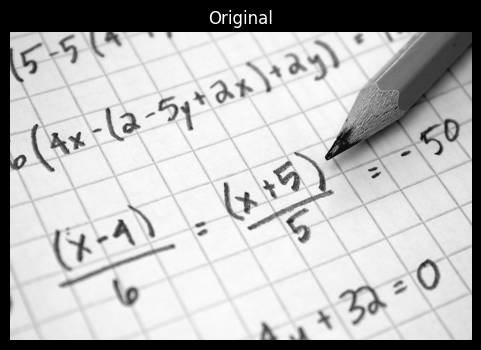

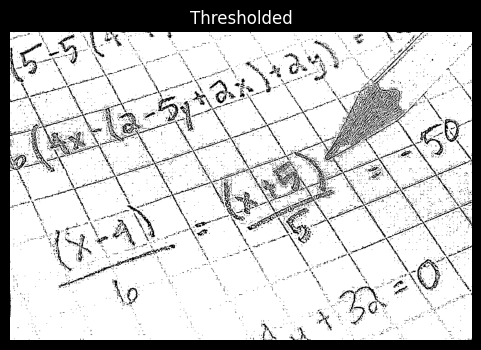

(667, 1000)


# Otra Umbralización automática con Otsu

En este ejemplo se utilizará la imagen `shape52.jpg` para aplicar una umbralización automática mediante el método de Otsu.

El objetivo es separar los objetos presentes en la imagen respecto al fondo utilizando un valor óptimo de umbral calculado automáticamente.

---

## Código

```python
from skimage.filters import threshold_otsu
from skimage.color import rgb2gray
import matplotlib.pyplot as plt

# Cargar imagen
image = plt.imread('../Images/shape52.jpg')

# Convertir imagen a escala de grises
gray_image = rgb2gray(image)

# Obtener valor óptimo de umbral
thresh = threshold_otsu(gray_image)

# Aplicar umbralización
binary_image = gray_image > thresh

# Mostrar imagen original
show_image(gray_image, 'Original')

# Mostrar imagen binarizada
show_image(binary_image.astype(float), 'Binarized image')
```

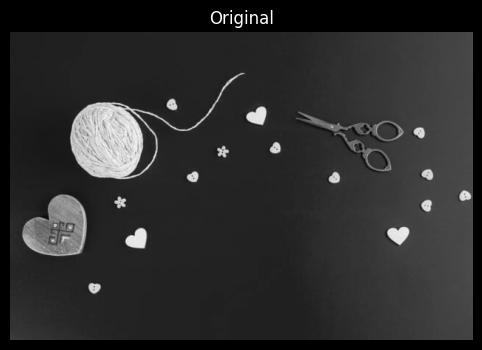

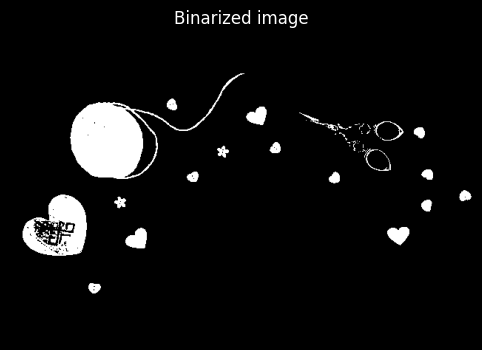